This is a very short notebook outlining the basic thoughts behind fractional Brownian motions. It is to be followed by at least 1 notebook on path signatures and some of their use cases.

A very non-rigorous way of describing an fBM is that it is like a normal BM but increments are not independent. One descrbies what type of fBM a process is by specifying its Hurst parameter $0<H<1$. For an fBM $W_t^H$ we have that $W_0^H = 0$, $\mathbb E [W_t^H] = 0$, and $\mathbb E[W^H_t\cdot W^H_s] = \frac{1}{2}(|t|^{2H} + |s|^{2H} - |t-s|^{2H})$.

For $H = 0.5$ a standard BM is recovered, for $H < 0.5$ increments of the process are negatively correlated, for $H > 0.5$ increments of thje process are positively correlated. If increments are negatively correlated ($H < 0.5$) then if the process moves up in one instant it is probably moving down in the near future which leads to very jagged and rough paths. If increments are positively correlated ($H > 0.5$) then if the process moves up in one instant it is probably moving up again in the near future which leads to very smooth paths.


We can quite easily simulate an fBM with Hurst parameter $0 < H < 1$ in the time interval $t\in [0, T]$ with $N$ increments (so that $\Delta T = \frac{T}{N}$) using the following scheme:

1. Generate $N$ increments $\Delta W_{t_n} \sim \sqrt{\Delta T} \mathcal N(0,1)$. Resulting in the vector $\Delta W$.
2. Calculate the covariance function $R^H({t_n}, {s_n}) = \frac{1}{2}(|{t_n}|^{2H} + |{s_n}|^{2H} - |{t_n}-{s_n}|^{2H})$ for all timepoints ${t_n},{s_n}$. Resulting in the covariance matrix $R_H$.
3. Calculate the Cholesky decomposition of $R^H$, i.e. find a real lower triangular matrix $L$ such that $R_H = LL^T$. And construct the increments $\Delta \hat{W} = L \Delta W$.
4. The fBM increments are then given by $\Delta \hat{W}$. So the process is given by $W^H_0 = 0, W^H_{t_n} = \sum_{i=1}^n \Delta \hat{W_{t_i}}$.

We see an example of this, for $H = 0.2, 0.5, 0.8$ below. There are more efficient algorithms using FFT and such, available e.g. via the python "fbm" package.

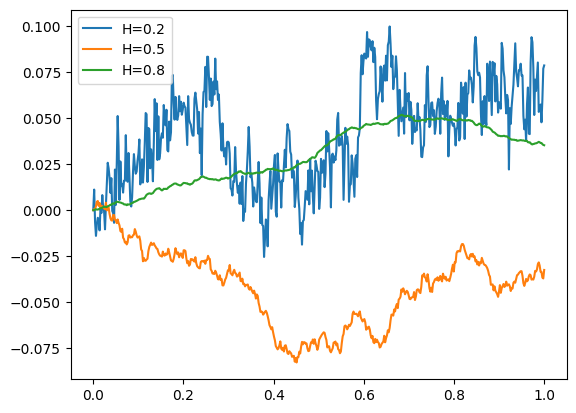

In [76]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def fBM_path(H=0.5, N=500, T=1):
    dt = T/N
    t_vec = np.linspace(0, T, N)

    increments = np.random.normal(size=N)*np.sqrt(dt)
    increments[0] = 0

    # dX_t = dW^H_t, no drift
    path = np.cumsum(increments)

    #corr R_H(s,t) = 1/2(s^2H + t^2H - |s - t|^2H)
    s_grid, t_grid = np.meshgrid(t_vec, t_vec)

    R_H = 0.5 * (s_grid**(2*H) + t_grid**(2*H) - np.abs(s_grid - t_grid)**(2*H))

    L = np.linalg.cholesky(R_H + 1e-10 * np.eye(N))
    fbm_path = L @ increments
    return fbm_path, t_vec

fbm_02, t_vec = fBM_path(H=0.2)
fbm_05, _ = fBM_path(H=0.5)
fbm_08, _ = fBM_path(H=0.8)


plt.plot(t_vec, fbm_02, label="H=0.2")
plt.plot(t_vec, fbm_05, label="H=0.5")
plt.plot(t_vec, fbm_08, label="H=0.8")
plt.legend()
plt.show()

Or with the fbm library:

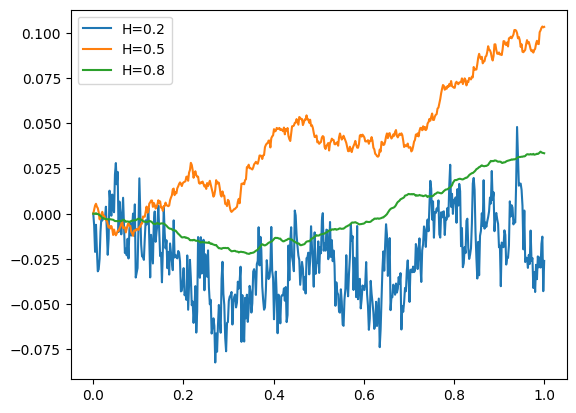

In [77]:
from fbm import fbm

fbm_02 = fbm(n=500-1, hurst=0.2, length=1)
fbm_05 = fbm(n=500-1, hurst=0.5, length=1)
fbm_08 = fbm(n=500-1, hurst=0.8, length=1)

dt = 1/500

plt.plot(t_vec, np.sqrt(dt)*fbm_02, label="H=0.2")
plt.plot(t_vec, np.sqrt(dt)*fbm_05, label="H=0.5")
plt.plot(t_vec, np.sqrt(dt)*fbm_08, label="H=0.8")
plt.legend()
plt.show()

One can continue from an endpoint and onwards of an fBM by considering the conditional Gaussian distribution correctly. Of course for $H=0.5$ it is straight forward to keep simulating from an endpoint, but for $H < 0.5$ and $H > 0.5$ one needs to consider the covariance of the future path with the entire past path.

Given data of a process governed by a fBM, we can examine what the Hurst parameter is. As I understand it this could be useful when working with path signatures as regressors or as features in some ML method. An fBM with hurst parameter $H$ has a finite $p$-variation for $p > 1/H$ and the norm of the $k$-th signature term for a path with finite $p$-variation can be shown to satisfy (Lyon's estimate?)

$$||\mathbb X^k_{0,T}|| \leq \frac{(C\cdot ||\mathbb X||_{p\text{-var}})^k}{\Gamma(\frac{k}{p} + 1)}.$$

The higher $p$ is the slower the denominator $\Gamma(\frac{k}{p} + 1)$ grows with $k$ leading to more terms being "significant".  

The method I will showcase is (I think) called the "Variogram method" and uses the fact that an fBM is so called self-similar with $W^H(at) \sim |a|^HW^H(t)$ and has stationary increments $W^H(t) - W^H(s) \sim W^H(t-s)$. Which means that $$W^H(t + \Delta t) - W^H(t) \sim W^H(\Delta t) \sim (\Delta t)^H W^H(1) \sim (\Delta t)^H \mathcal N(0, 1).$$ This gives us then that $$\mathbb E[W^H(t + \Delta t) - W^H(t)] = (\Delta t)^H.$$ More generally $$\mathbb E[|W^H(t+\Delta t) - W^H(t)|^q] = \mathbb E[|(\Delta t)^H\mathcal N(0, 1)|^q] = (\Delta t)^{Hq} \cdot \mathbb E[|\mathcal N(0, 1)|^q] = C_q\cdot (\Delta t)^{hq}.$$

This then motivates our method, which calculates $$V(\Delta t) = \frac{1}{N-\Delta t}\sum_{t=1}^{N-\Delta t} |X_{t+\Delta t} - X_t|^q$$ for several different $\Delta t$ and some $q$. Then we do linear regression on $\log(V(\Delta t))$ against $\log(\Delta t)$ to get the slope $\beta$, our estimated Hurst parameter is then $$H = \frac{H}{q}.$$

Below is an AI generated code snippet that does this exact thing, which we test for the above paths.

In [78]:
def estimate_hurst_variogram(path, max_lag=100, q=2):
    lags = np.arange(1, max_lag + 1)
    variog_values = []
    
    # 1. Compute the q-th sample absolute moment for each lag
    for lag in lags:
        # Vectorized difference: X_(t + lag) - X_t
        absolute_increments = np.abs(path[lag:] - path[:-lag])
        # Compute the average q-th moment
        moment = np.mean(absolute_increments ** q)
        variog_values = np.append(variog_values, moment)
        
    # 2. Perform linear regression on the log-log data
    # log(Moment) = slope * log(Lag) + intercept
    slope, _ = np.polyfit(np.log(lags), np.log(variog_values), 1)
    
    # 3. Extract H using the theoretical scaling relation: slope = q * H
    H = slope / q
    return H

# Estimate Hurst
estimate_02 = estimate_hurst_variogram(fbm_02, max_lag=10, q=2)
estimate_05 = estimate_hurst_variogram(fbm_05, max_lag=10, q=2)
estimate_08 = estimate_hurst_variogram(fbm_08, max_lag=10, q=2)

print(f"Estimated Hurst Parameter for H=0.2: {estimate_02:.3f}")
print(f"Estimated Hurst Parameter for H=0.5: {estimate_05:.3f}")
print(f"Estimated Hurst Parameter for H=0.8: {estimate_08:.3f}")

Estimated Hurst Parameter for H=0.2: 0.199
Estimated Hurst Parameter for H=0.5: 0.507
Estimated Hurst Parameter for H=0.8: 0.826


It works quite good! Increasing max_lag would give lower variance samples but also reduce the number of samples in the final expectation. Decreasing max_lag isntead makes every sample more noisy but we get more of them in the expectation. The formula holds for every q but sometimes one can get unlucky with real world data or generated data if large jumps create artifacts.